Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...


Loading Tomato_Septoria_leaf_spot: 100%|██████████| 175/175 [00:21<00:00,  8.33it/s]
Loading Tomato_Spider_mites_Two-spotted_spider_mite: 100%|██████████| 175/175 [00:20<00:00,  8.73it/s]
Loading Tomato_Tomato_mosaic_virus: 100%|██████████| 175/175 [00:10<00:00, 16.54it/s]



Healthy Images : 1575
Diseased Images: 1575

Training ImprovedFuzzySoft...

Training LDA...

Training SVM...

Training RandomForest...

Training NaiveBayes...

PERFORMANCE COMPARISON
                   Accuracy  Precision  Recall  F1-Score  Specificity     AUC
ImprovedFuzzySoft    0.8857     0.8240  0.9810    0.8957       0.7905  0.8427
LDA                  0.9492     0.9639  0.9333    0.9484       0.9651  0.9916
SVM                  0.9794     0.9840  0.9746    0.9793       0.9841  0.9971
RandomForest         0.9778     0.9808  0.9746    0.9777       0.9810  0.9975
NaiveBayes           0.8238     0.9180  0.7111    0.8014       0.9365  0.9374


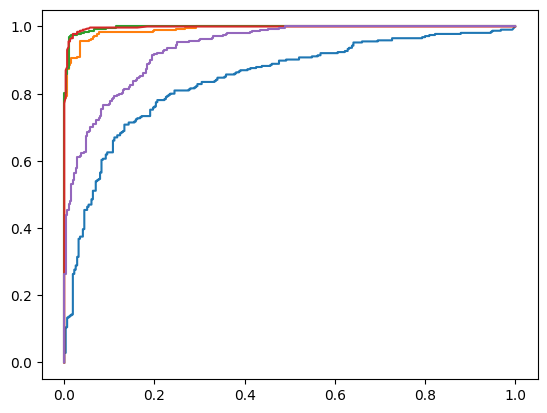

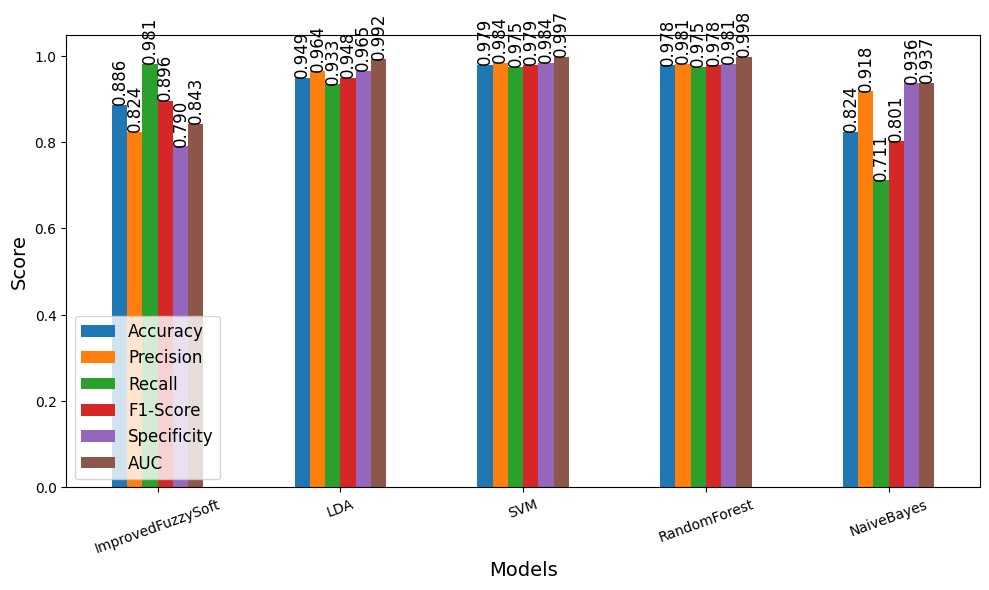


5-FOLD CROSS VALIDATION
ImprovedFuzzySoft    : 0.8994 ± 0.0137
LDA                  : 0.9505 ± 0.0084
SVM                  : 0.9733 ± 0.0043
RandomForest         : 0.9784 ± 0.0092
NaiveBayes           : 0.8197 ± 0.0124

📊 Combined Confusion Tables

ImprovedFuzzySoft Confusion Matrix:
[[249  66]
 [  6 309]]

LDA Confusion Matrix:
[[304  11]
 [ 21 294]]

SVM Confusion Matrix:
[[310   5]
 [  8 307]]

RandomForest Confusion Matrix:
[[309   6]
 [  8 307]]

NaiveBayes Confusion Matrix:
[[295  20]
 [ 91 224]]


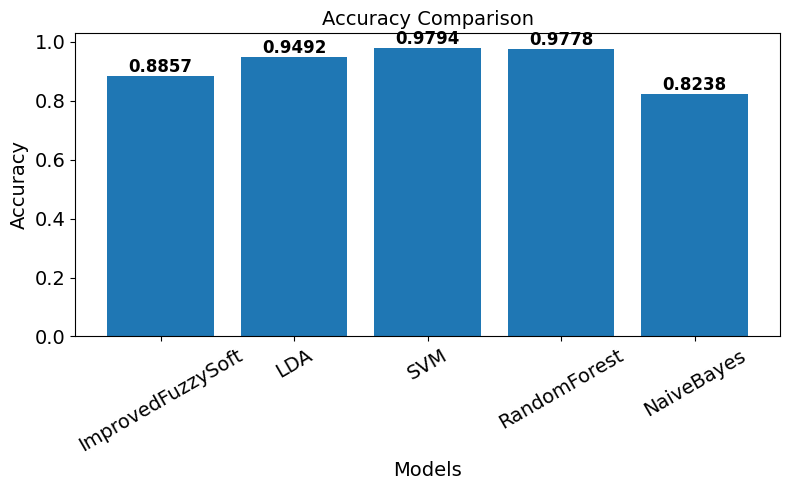

/tmp/ipykernel_1401/2371030927.py:481: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


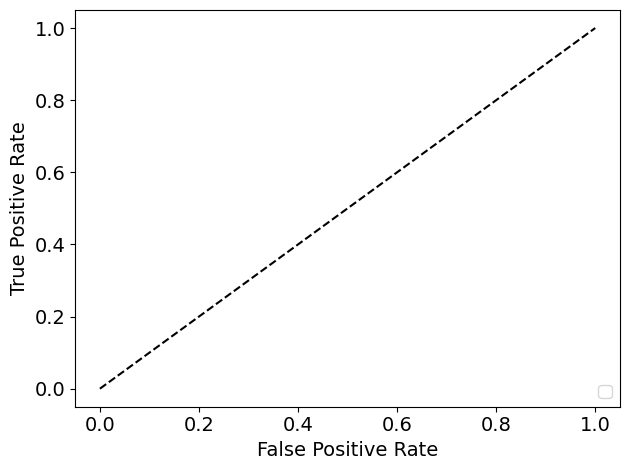

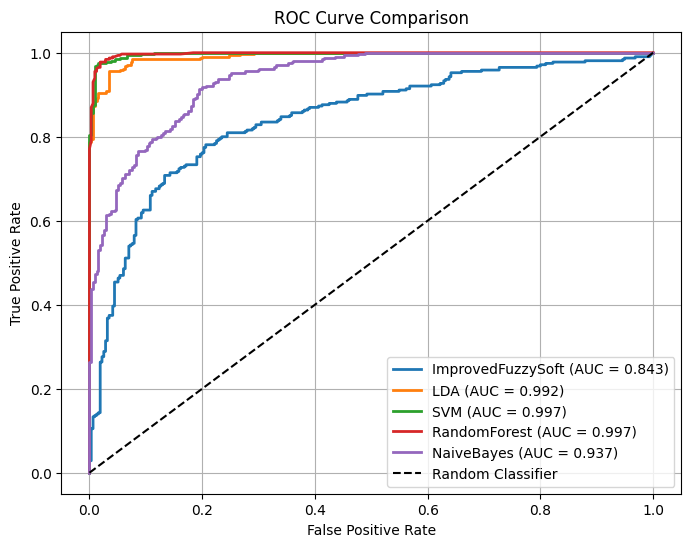


Ablation Study
Without Weights: 0.9142857142857143
With Weights: {'Accuracy': 0.8857142857142857, 'Precision': 0.824, 'Recall': 0.9809523809523809, 'F1-Score': 0.8956521739130435, 'Specificity': np.float64(0.790476190451096), 'AUC': np.float64(0.8427110103300579)}

INTERPRETABILITY ANALYSIS

Feature Importance Ranking
            Feature    Weight
9  GLCM_Correlation  0.466583
6     GLCM_Contrast  0.258969
4             HSV_S  0.187947
3             HSV_H  0.045852
8  GLCM_Homogeneity  0.032266
2             RGB_B  0.004279
5             HSV_V  0.001878
0             RGB_R  0.001296
7       GLCM_Energy  0.000840
1             RGB_G  0.000088

Top 5 Most Important Features
            Feature    Weight
9  GLCM_Correlation  0.466583
6     GLCM_Contrast  0.258969
4             HSV_S  0.187947
3             HSV_H  0.045852
8  GLCM_Homogeneity  0.032266


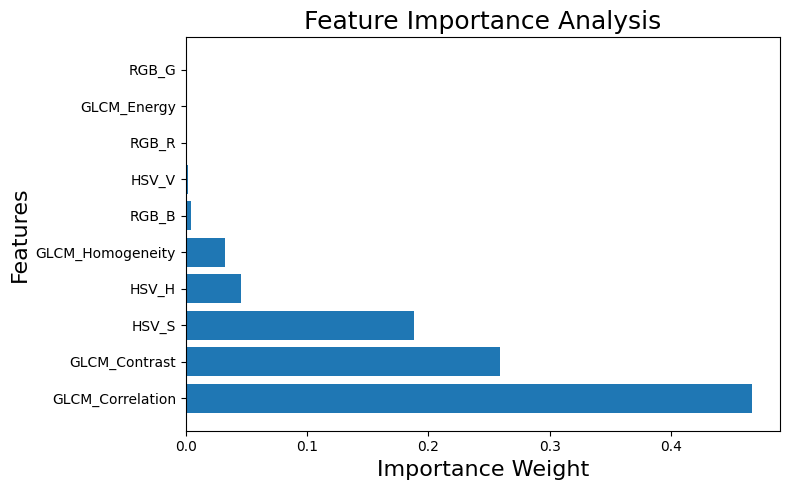

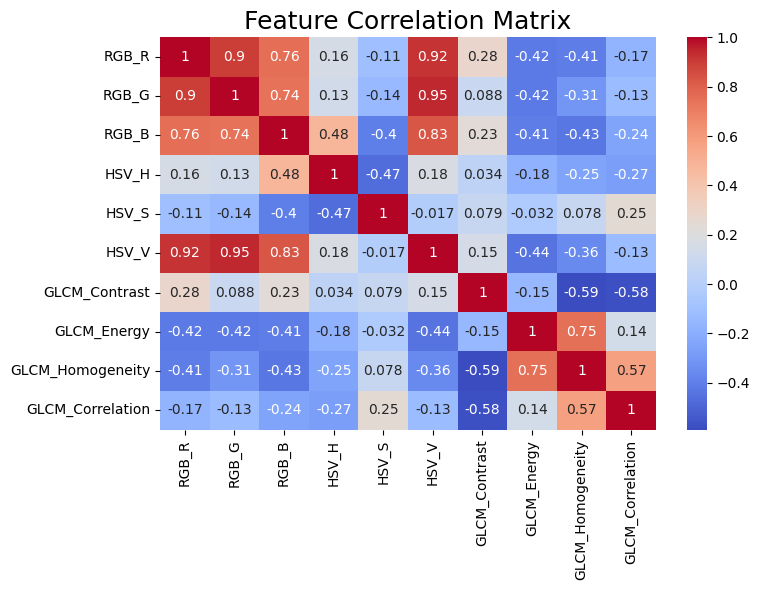

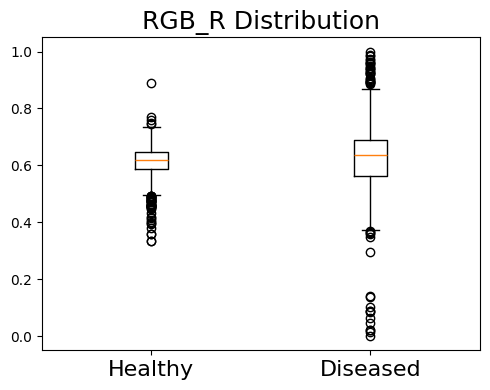

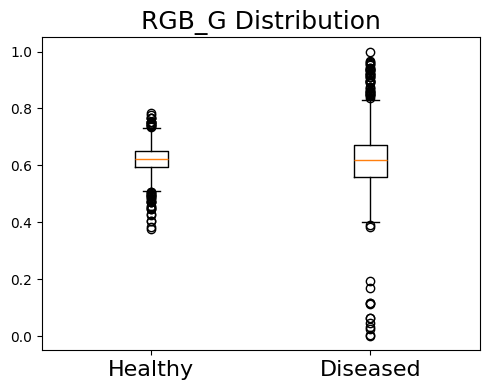

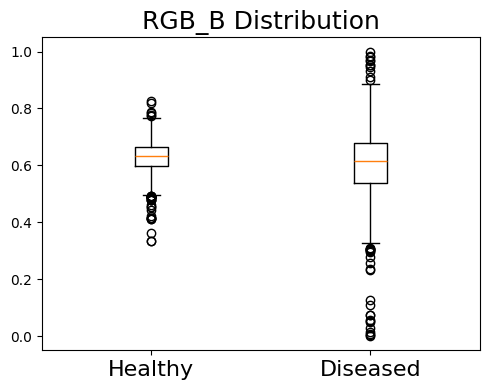

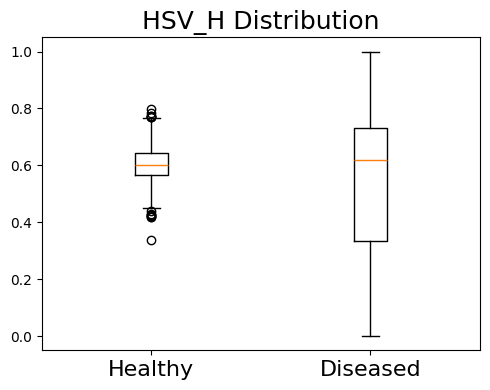

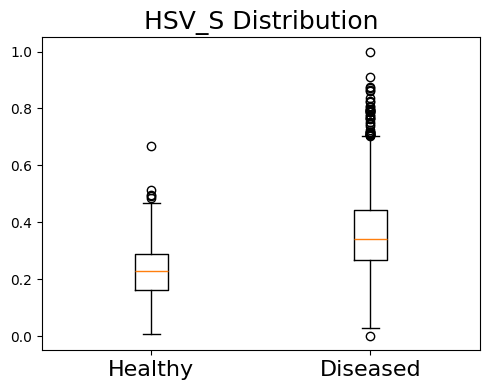

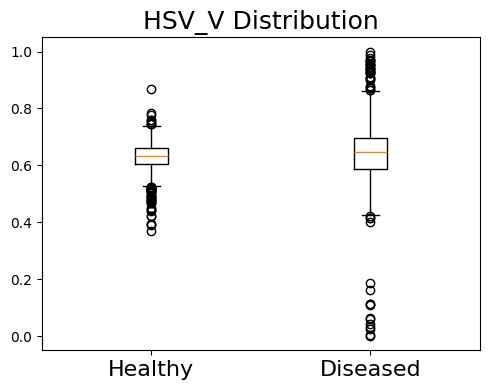

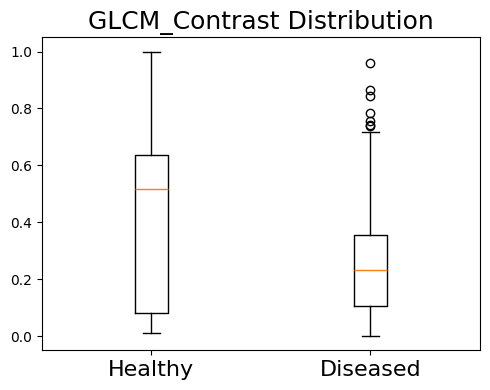

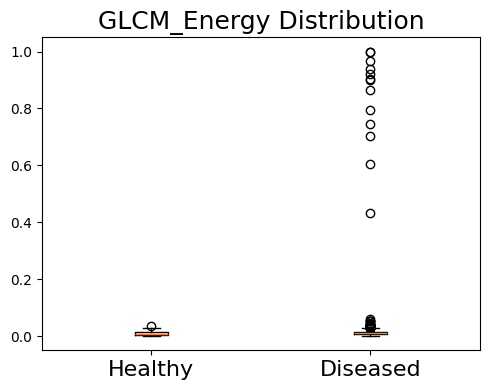

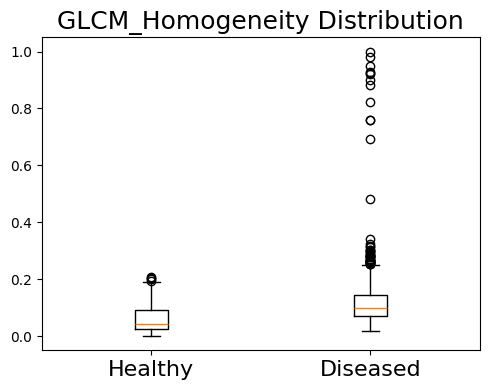

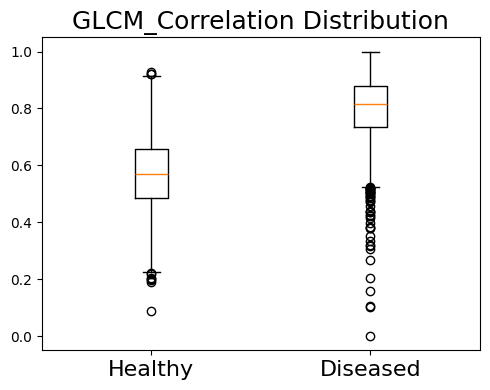


Prototype Analysis

Class 0 Prototypes
      RGB_R     RGB_G     RGB_B     HSV_H     HSV_S     HSV_V  GLCM_Contrast  \
0  0.000765  0.000055  0.002663  0.028421  0.025821  0.001166       0.015850   
1  0.000820  0.000055  0.002748  0.027703  0.051150  0.001200       0.159905   
2  0.000745  0.000054  0.002560  0.027476  0.031304  0.001145       0.024961   

   GLCM_Energy  GLCM_Homogeneity  GLCM_Correlation  
0     0.000015          0.004061          0.359916  
1     0.000004          0.000986          0.241026  
2     0.000014          0.002804          0.262331  

Class 1 Prototypes
      RGB_R     RGB_G     RGB_B     HSV_H     HSV_S     HSV_V  GLCM_Contrast  \
0  0.000854  0.000056  0.002788  0.031992  0.068010  0.001277       0.061127   
1  0.000874  0.000057  0.002780  0.024469  0.066771  0.001279       0.105201   
2  0.000749  0.000052  0.002428  0.022953  0.069677  0.001137       0.033416   

   GLCM_Energy  GLCM_Homogeneity  GLCM_Correlation  
0     0.000013          0.003048 

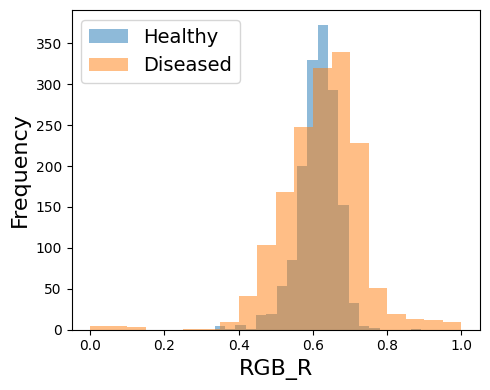

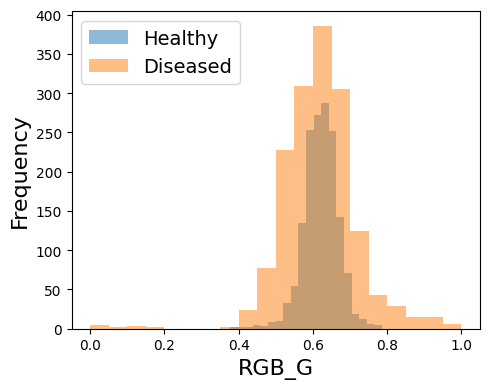

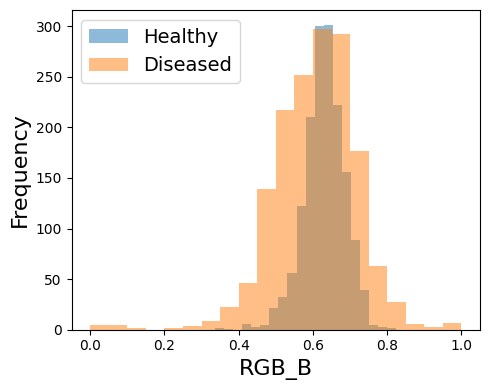

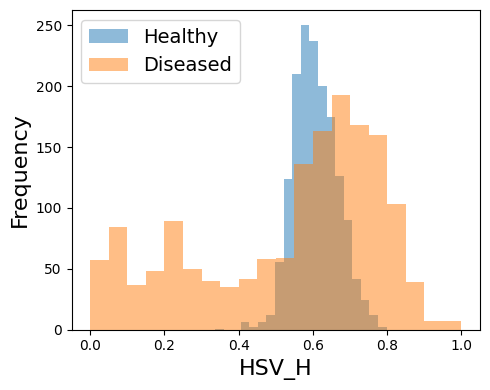

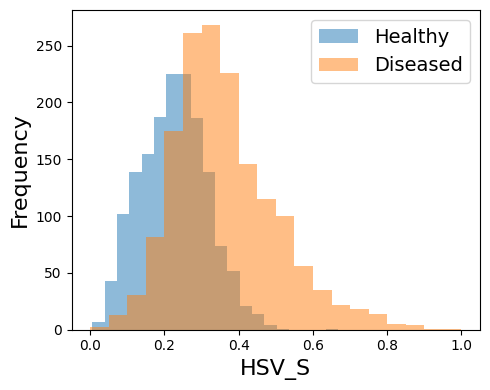

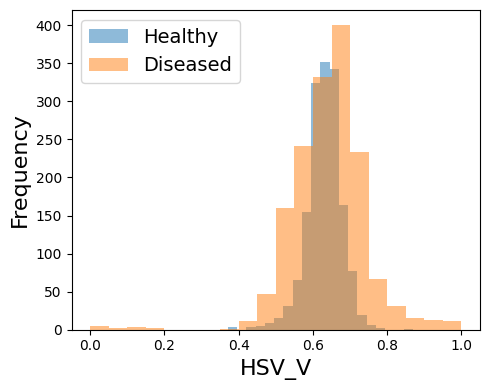

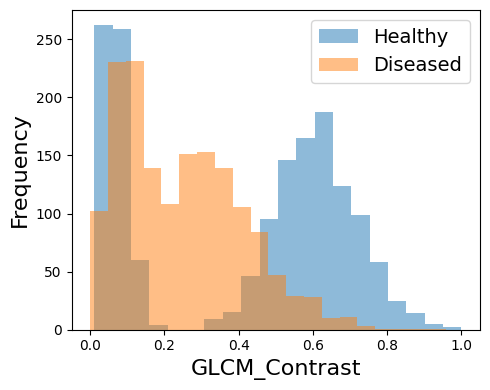

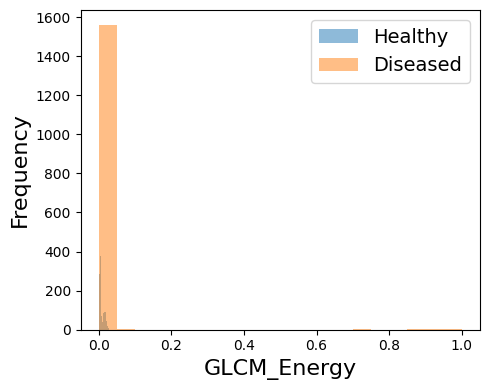

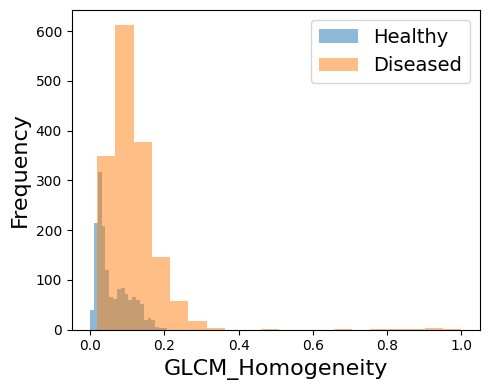

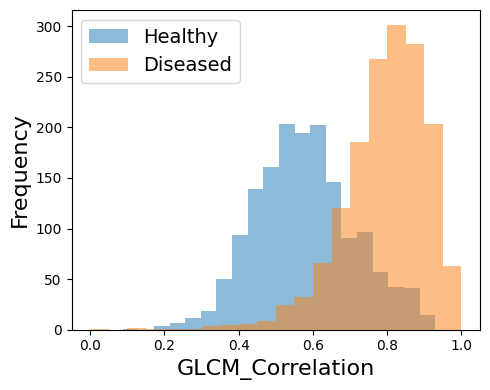


Wilcoxon Test (Fuzzy vs RandomForest)
Statistic: 172.5
p-value: 2.013681389187048e-12
            Feature  Healthy_Mean  Diseased_Mean  U_Statistic        P_Value  \
9  GLCM_Correlation      0.577393       0.794675     274986.0   0.000000e+00   
4             HSV_S      0.226534       0.364531     494318.5  8.190451e-188   
8  GLCM_Homogeneity      0.059922       0.116814     536959.0  3.478058e-167   
6     GLCM_Contrast      0.410767       0.247155    1621998.0   1.441429e-50   
7       GLCM_Energy      0.009400       0.018403     968151.0   1.503363e-26   
5             HSV_V      0.629860       0.642360    1082149.0   5.750122e-10   
2             RGB_B      0.629923       0.606480    1394770.5   1.431087e-09   
0             RGB_R      0.613342       0.624451    1090227.0   4.087313e-09   
1             RGB_G      0.621381       0.617816    1301201.0   1.704621e-02   
3             HSV_H      0.606263       0.536927    1221366.5   4.578927e-01   

   Cohens_d  
9  1.731264  
4  1

In [13]:
# ==========================================
# FULL ENHANCED PIPELINE (ORIGINAL + ADDED ANALYSIS)
# ==========================================

import os
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    confusion_matrix
)

from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold
# ==============================
# SEED
# ==============================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


from google.colab import drive
drive.mount('/content/drive')
# ==============================
# CONFIG
# ==============================
DATASET_PATH = "/content/drive/MyDrive/PlantVillageDataset"
IMG_SIZE = (128, 128)
# ==============================
# FEATURE NAMES
# ==============================
feature_names = [
    "RGB_R",
    "RGB_G",
    "RGB_B",
    "HSV_H",
    "HSV_S",
    "HSV_V",
    "GLCM_Contrast",
    "GLCM_Energy",
    "GLCM_Homogeneity",
    "GLCM_Correlation"
]
# ==============================
# IMAGE + FEATURES
# ==============================
def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    return np.array(img)

def extract_features(img):

    rgb = np.mean(img, axis=(0, 1))

    hsv = np.array(Image.fromarray(img).convert("HSV"))
    hsv = np.mean(hsv, axis=(0, 1))

    gray = np.dot(img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

    glcm = graycomatrix(gray, [1,2], [0, np.pi/4, np.pi/2],
                        symmetric=True, normed=True)

    texture = [
        graycoprops(glcm, 'contrast').mean(),
        graycoprops(glcm, 'energy').mean(),
        graycoprops(glcm, 'homogeneity').mean(),
        graycoprops(glcm, 'correlation').mean()
    ]

    return np.concatenate([rgb, hsv, texture])

# ==============================
# NORMALIZATION
# ==============================
def normalize(X):
    X = np.nan_to_num(X)
    return (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-8)

# ==============================
# LOAD DATASET (BINARY)
# ==============================
def load_dataset():
    X, y = [], []

    healthy_folder = "Tomato_healthy"

    disease_folders = [
        "Tomato_Bacterial_spot",
        "Tomato_Early_blight",
        "Tomato_Late_blight",
        "Tomato_Leaf_Mold",
        "Tomato_Septoria_leaf_spot",
        "Tomato_Spider_mites_Two-spotted_spider_mite",
        "Tomato_Target_Spot",
        "Tomato_Tomato_Yellow_Leaf_Curl_Virus",
        "Tomato_Tomato_mosaic_virus"
    ]

    # =====================
    # HEALTHY (1575 images)
    # =====================
    folder = os.path.join(DATASET_PATH, healthy_folder)

    healthy_imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    ]

    selected_healthy = random.sample(
        healthy_imgs,
        min(1575, len(healthy_imgs))
    )

    for img_name in tqdm(selected_healthy,
                         desc="Loading Healthy"):
        try:
            img = preprocess_image(
                os.path.join(folder, img_name)
            )

            feat = extract_features(img)

            X.append(feat)
            y.append(0)

        except:
            continue

    # =====================
    # DISEASED
    # 175 from each folder
    # =====================
    for disease in disease_folders:

        folder = os.path.join(
            DATASET_PATH,
            disease
        )

        imgs = [
            f for f in os.listdir(folder)
            if f.lower().endswith(
                ('.jpg','.jpeg','.png')
            )
        ]

        selected = random.sample(
            imgs,
            min(175, len(imgs))
        )

        for img_name in tqdm(
            selected,
            desc=f"Loading {disease}"
        ):
            try:

                img = preprocess_image(
                    os.path.join(folder, img_name)
                )

                feat = extract_features(img)

                X.append(feat)
                y.append(1)

            except:
                continue

    print("\nHealthy Images :", np.sum(np.array(y)==0))
    print("Diseased Images:", np.sum(np.array(y)==1))

    return np.array(X), np.array(y)
# ==============================
# IMPROVED FUZZY SOFT MODEL
# ==============================
class ImprovedFuzzySoft:

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.prototypes = {}
        self.cov_inv = {}
        self.sigmas = {}

        self.weights = self.compute_weights(X, y)
        Xw = X * self.weights

        for cls in self.classes:
            data = Xw[y == cls]

            km = KMeans(n_clusters=3, random_state=SEED).fit(data)
            self.prototypes[cls] = km.cluster_centers_

            cov = np.cov(data.T) + np.eye(data.shape[1]) * 1e-5
            self.cov_inv[cls] = np.linalg.inv(cov)

            self.sigmas[cls] = np.std(data) + 1e-6

    def compute_weights(self, X, y):
        weights = []
        for i in range(X.shape[1]):
            f = X[:, i]
            means = [np.mean(f[y == c]) for c in np.unique(y)]
            weights.append(np.var(means))
        w = np.array(weights)
        return w / (np.sum(w) + 1e-8)

    def mahalanobis(self, x, mean, cov_inv):
        diff = x - mean
        return np.sqrt(diff @ cov_inv @ diff.T)

    def similarity(self, x, cls):
        sims = []

        for c in self.prototypes[cls]:
            dist = self.mahalanobis(x, c, self.cov_inv[cls])
            sigma = self.sigmas[cls]
            sims.append(np.exp(-(dist**2) / (2 * sigma**2)))

        sims = sorted(sims, reverse=True)[:2]
        return np.mean(sims)

    def predict_proba(self, X):
        Xw = X * self.weights
        probs = []

        for x in Xw:
            scores = [self.similarity(x, c) for c in self.classes]
            scores = np.array(scores)
            probs.append(scores / (np.sum(scores) + 1e-8))

        return np.array(probs)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# ==============================
# CROSS VALIDATION
# ==============================
from sklearn.model_selection import StratifiedKFold
def cross_validate_model(model, X, y, folds=5):

    skf = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    scores = []

    for train_idx, test_idx in skf.split(X, y):

        X_train_cv = X[train_idx]
        X_test_cv = X[test_idx]

        y_train_cv = y[train_idx]
        y_test_cv = y[test_idx]

        model.fit(X_train_cv, y_train_cv)

        y_pred_cv = model.predict(X_test_cv)

        acc = accuracy_score(
            y_test_cv,
            y_pred_cv
        )

        scores.append(acc)

    return np.array(scores)

# ==============================
# MAIN
# ==============================
if __name__ == "__main__":

    print("Loading data...")
    X, y = load_dataset()

    X = normalize(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    models = {
        "ImprovedFuzzySoft": ImprovedFuzzySoft(),
        "LDA": LinearDiscriminantAnalysis(),
        "SVM": SVC(probability=True),
        "RandomForest": RandomForestClassifier(),
        "NaiveBayes": GaussianNB()
    }

    results = {}
    predictions = {}
    conf_tables = {}
    roc_data = {}

    plt.figure()

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        predictions[name] = y_pred

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)

        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp + 1e-8)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        roc_data[name] = (fpr, tpr, roc_auc)

        results[name] = {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Specificity": specificity,
            "AUC": roc_auc
        }

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={roc_auc:.3f})"
        )

        conf_tables[name] = cm

    print("\n================================================")
    print("PERFORMANCE COMPARISON")
    print("================================================")

    results_df = pd.DataFrame(results).T

    results_df = results_df.round(4)

    print(results_df)
    ax=results_df.plot(
        kind='bar',
        figsize=(10,6)
    )
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            rotation=90,
            fontsize=12
        )
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("Models", fontsize=14)

    plt.xticks(rotation=20)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    print("\n================================================")
    print("5-FOLD CROSS VALIDATION")
    print("================================================")

    cv_results = {}

    for name, model in models.items():

        scores = cross_validate_model(model,X,y,folds=5)

        cv_results[name] = scores

        print(
            f"{name:20s} : "
            f"{scores.mean():.4f} ± {scores.std():.4f}"
        )

    # ==========================
    # SINGLE CONFUSION TABLE
    # ==========================
    print("\n📊 Combined Confusion Tables")
    for k, cm in conf_tables.items():
        print(f"\n{k} Confusion Matrix:")
        print(cm)
    # ==========================
    # Accuracy Histogram
    # ==========================
    plt.figure(figsize=(8,5))

    model_names = list(results.keys())
    accuracies = [results[m]["Accuracy"] for m in model_names]

    bars=plt.bar(model_names, accuracies)
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )
    plt.ylabel("Accuracy", fontsize=14)
    plt.xlabel("Models", fontsize=14)

    plt.xticks(rotation=30, fontsize=14)
    plt.yticks(fontsize=14)

    plt.title("Accuracy Comparison", fontsize=14)
    plt.ylim(0, max(accuracies) + 0.05)
    plt.tight_layout()
    plt.show()

    # ==========================
    # ROC CURVE
    # ==========================
    # Random classifier line
    plt.plot(
        [0,1],
        [0,1],
        'k--',
        linewidth=1.5
    )

    # Axis labels
    plt.xlabel(
        'False Positive Rate',
        fontsize=14
    )

    plt.ylabel(
        'True Positive Rate',
        fontsize=14
    )

    # Tick labels
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Legend
    plt.legend(
        loc='lower right',
        fontsize=12,
        frameon=True
    )

    plt.tight_layout()

    plt.savefig(
        'ROC_Curve.tif',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()

    # ==========================
    # ROC CURVE
    # ==========================

    plt.figure(figsize=(8,6))

    for name, (fpr, tpr, roc_auc) in roc_data.items():

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})'
        )

    plt.plot([0,1],[0,1],'k--', label='Random Classifier')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # ==========================
    # ABLATION STUDY
    # ==========================
    print("\nAblation Study")
    fs_no_weight = ImprovedFuzzySoft()
    fs_no_weight.compute_weights = lambda X,y: np.ones(X.shape[1])

    fs_no_weight.fit(X_train, y_train)
    y_pred_ab = fs_no_weight.predict(X_test)
    acc_ab = accuracy_score(y_test, y_pred_ab)

    print("Without Weights:", acc_ab)
    print("With Weights:", results["ImprovedFuzzySoft"])

    # ==========================
    # INTERPRETABILITY ANALYSIS
    # ==========================

    print("\n================================================")
    print("INTERPRETABILITY ANALYSIS")
    print("================================================")

    fuzzy_model = models["ImprovedFuzzySoft"]

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": fuzzy_model.weights
    })

    importance_df = importance_df.sort_values(
        by="Weight",
        ascending=False
    )

    print("\nFeature Importance Ranking")
    print(importance_df)
    print("\nTop 5 Most Important Features")

    print(
        importance_df.head(5)
    )
    # Feature Importance Plot

    plt.figure(figsize=(8,5))

    plt.barh(
        importance_df["Feature"],
        importance_df["Weight"]
    )

    plt.xlabel("Importance Weight",fontsize=16)
    plt.ylabel("Features",fontsize=16)
    plt.title("Feature Importance Analysis",fontsize=18)

    plt.tight_layout()
    plt.show()

    # ==========================
    # FEATURE CORRELATION
    # ==========================

    feature_df = pd.DataFrame(
        X,
        columns=feature_names
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        feature_df.corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title(
        "Feature Correlation Matrix",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

    # ==========================
    # CLASS-WISE DISTRIBUTION
    # ==========================

    for i, feature in enumerate(feature_names):

        plt.figure(figsize=(5,4))

        plt.boxplot([
            X[y == 0][:, i],
            X[y == 1][:, i]
        ])

        plt.xticks(
            [1,2],
            ["Healthy", "Diseased"],
            fontsize=16
        )

        plt.title(
            f"{feature} Distribution",
            fontsize=18
        )

        plt.tight_layout()
        plt.show()

    # ==========================
    # PROTOTYPE ANALYSIS
    # ==========================

    print("\nPrototype Analysis")

    for cls in fuzzy_model.classes:

        print(f"\nClass {cls} Prototypes")

        proto_df = pd.DataFrame(
            fuzzy_model.prototypes[cls],
            columns=feature_names
        )

        print(proto_df)

    # ==========================
    # FEATURE OVERLAP ANALYSIS
    # ==========================

    for i, feature in enumerate(feature_names):

        plt.figure(figsize=(5,4))

        plt.hist(
            X[y==0][:,i],
            bins=20,
            alpha=0.5,
            label='Healthy'
        )

        plt.hist(
            X[y==1][:,i],
            bins=20,
            alpha=0.5,
            label='Diseased'
        )

        plt.xlabel(feature, fontsize=16)
        plt.ylabel('Frequency', fontsize=16)
        plt.legend(fontsize=14)

        plt.tight_layout()
        plt.show()
    # ==========================
    # WILCOXON TEST
    # ==========================
    print("\nWilcoxon Test (Fuzzy vs RandomForest)")

    correct_fuzzy = (
        predictions["ImprovedFuzzySoft"] == y_test
    ).astype(int)

    correct_rf = (
        predictions["RandomForest"] == y_test
    ).astype(int)

    stat, p = wilcoxon(correct_fuzzy, correct_rf)
    print("Statistic:", stat)
    print("p-value:",p)


    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu

    feature_names = [
        'RGB_R','RGB_G','RGB_B',
        'HSV_H','HSV_S','HSV_V',
        'GLCM_Contrast','GLCM_Energy',
        'GLCM_Homogeneity','GLCM_Correlation'
    ]

    healthy = X[y == 0]
    diseased = X[y == 1]

    results = []

    for i, feat in enumerate(feature_names):

        h = healthy[:, i]
        d = diseased[:, i]

        # Mann-Whitney U Test
        stat, p = mannwhitneyu(
            h,
            d,
            alternative='two-sided'
        )

        # Cohen's d
        pooled_std = np.sqrt(
            (
                ((len(h)-1) * np.var(h, ddof=1))
                +
                ((len(d)-1) * np.var(d, ddof=1))
            )
            /
            (len(h) + len(d) - 2)
        )

        cohen_d = (
            np.mean(d) - np.mean(h)
        ) / pooled_std

        results.append([
            feat,
            np.mean(h),
            np.mean(d),
            stat,
            p,
            cohen_d
        ])

    df_stats = pd.DataFrame(
        results,
        columns=[
            'Feature',
            'Healthy_Mean',
            'Diseased_Mean',
            'U_Statistic',
            'P_Value',
            'Cohens_d'
        ]
    )

    df_stats = df_stats.sort_values(
        by='P_Value'
    )

    print(df_stats)

    df_stats.to_csv(
        'Feature_Overlap_Statistics.csv',
        index=False
    )

    from scipy.stats import gaussian_kde

    overlap_scores = []

    for i, feat in enumerate(feature_names):

        h = healthy[:, i]
        d = diseased[:, i]

        xmin = min(h.min(), d.min())
        xmax = max(h.max(), d.max())

        xgrid = np.linspace(xmin, xmax, 1000)

        kde_h = gaussian_kde(h)
        kde_d = gaussian_kde(d)

        pdf_h = kde_h(xgrid)
        pdf_d = kde_d(xgrid)

        overlap = np.trapezoid(
            np.minimum(pdf_h, pdf_d),
            xgrid
        )

        overlap_scores.append(
            [feat, overlap]
        )

    df_overlap = pd.DataFrame(
        overlap_scores,
        columns=[
            'Feature',
            'Overlap_Coefficient'
        ]
    )

    print(df_overlap.sort_values(
        by='Overlap_Coefficient',
        ascending=False
    ))

    comparison_results = {}

    for name, model in models.items():

        # Training
        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start

        # Prediction
        start = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - start

        acc = accuracy_score(y_test, y_pred)

        comparison_results[name] = {
            "Accuracy": acc,
            "Training Time (s)": train_time,
            "Inference Time (s)": inference_time
        }

    comparison_df = pd.DataFrame(comparison_results).T
    comparison_df = comparison_df.round(6)

    print(comparison_df)
    print("\n======================================")
    print("COMPUTATIONAL TIME COMPARISON")
    print("======================================")
    print(comparison_df)
    print(
        comparison_df.to_latex(
            float_format="%.4f",
            caption="Training and inference time comparison of the evaluated classifiers.",
            label="tab:timing_comparison"
        )
    )

    # ==========================================================
# CROSS-DATASET VALIDATION
# Train  : PlantVillage
# Test   : PlantDocTomato
# ==========================================================

import os
import cv2
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ----------------------------------------------------------
# MODIFY THIS PATH
# ----------------------------------------------------------

PLANTDOC_TEST_DIR = "/content/drive/MyDrive/PlantDocTomatoDataset"

# ----------------------------------------------------------
# LOAD PLANTDOC DATASET
# ----------------------------------------------------------

def load_plantdoc_dataset(base_dir,
                          img_size=(128,128)):

    images = []
    labels = []

    folders = sorted(os.listdir(base_dir))

    print("\nPlantDoc Classes:")
    print(folders)

    for folder in folders:

        folder_path = os.path.join(base_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        # Healthy = 0
        # Everything else = Diseased = 1

        if folder == "Healthy":
            label = 0
        else:
            label = 1

        image_files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(
                ('.jpg','.jpeg','.png')
            )
        ]

        for file in image_files:

            img_path = os.path.join(
                folder_path,
                file
            )

            try:

                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(
                    img,
                    img_size
                )

                images.append(img)
                labels.append(label)

            except:
                continue

    return (
        np.array(images),
        np.array(labels)
    )

# ----------------------------------------------------------
# LOAD PLANTDOC TEST SET
# ----------------------------------------------------------

print("\nLoading PlantDocTomato dataset...")

X_doc_images, y_doc = load_plantdoc_dataset(
    PLANTDOC_TEST_DIR
)

print("\nPlantDoc samples:",
      len(X_doc_images))

print("Healthy:",
      np.sum(y_doc == 0))

print("Diseased:",
      np.sum(y_doc == 1))

# ----------------------------------------------------------
# FEATURE EXTRACTION
# USE YOUR EXISTING FEATURE FUNCTION
# ----------------------------------------------------------

print("\nExtracting PlantDoc features...")
print(type(X_doc_images))
print(X_doc_images.shape)

print(type(X_doc_images[0]))
print(X_doc_images[0].shape)


X_doc_features = []

for img in X_doc_images:

    feats = extract_features(img)

    X_doc_features.append(feats)

X_doc_features = np.array(X_doc_features)

# ----------------------------------------------------------
# NORMALIZATION
# IMPORTANT:
# Use SAME scaler as PlantVillage
# ----------------------------------------------------------

X_doc_features = normalize(
    X_doc_features
)

# ----------------------------------------------------------
# TRAIN ON ENTIRE PLANTVILLAGE DATASET
# ----------------------------------------------------------

X_train_cross = X
y_train_cross = y

X_test_cross = X_doc_features
y_test_cross = y_doc

# ----------------------------------------------------------
# MODELS
# ----------------------------------------------------------

cross_results = {}

for name, model in models.items():

    print("\n================================")
    print("Cross Dataset:", name)
    print("================================")

    model.fit(
        X_train_cross,
        y_train_cross
    )

    y_pred = model.predict(
        X_test_cross
    )

    acc = accuracy_score(
        y_test_cross,
        y_pred
    )

    prec = precision_score(
        y_test_cross,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test_cross,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_cross,
        y_pred,
        zero_division=0
    )

    try:

        if hasattr(model,
                   "predict_proba"):

            y_prob = model.predict_proba(
                X_test_cross
            )[:,1]

        else:

            y_prob = model.decision_function(
                X_test_cross
            )

        auc = roc_auc_score(
            y_test_cross,
            y_prob
        )

    except:

        auc = np.nan

    cross_results[name] = {

        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": auc
    }

# ----------------------------------------------------------
# RESULTS TABLE
# ----------------------------------------------------------

cross_df = pd.DataFrame(
    cross_results
).T

cross_df = cross_df.round(4)

print("\n")
print("===================================================")
print("PLANTVILLAGE -> PLANTDOCTOMATO")
print("CROSS-DATASET EVALUATION RESULTS")
print("===================================================")

print(cross_df)

# ----------------------------------------------------------
# LATEX TABLE
# ----------------------------------------------------------

print("\nLATEX TABLE\n")

print(
    cross_df.to_latex(
        float_format="%.4f",
        caption=
        "Cross-dataset evaluation using PlantVillage for training and PlantDocTomato for testing.",
        label=
        "tab:cross_dataset"
    )
)
